# Part 4: Gradient Descent in Code

This notebook converts the **Part 3 manual calculations** into Python code using matrix operations.

### Linear model
$$\hat{y} = X \mathbf{m} + \mathbf{b}$$

### Given (from Part 3)

| Symbol | Value |
|--------|-------|
| `m` (weights) | `[-1, 2]` |
| `b` (bias) | `[1, 1]` |
| `X` (inputs) | `[[1, 3], [4, 10]]` |
| `y` (targets) | `[5, 6]` |
| Learning rate | `0.01` |
| Iterations | `4` (one per group member) |

### Cost function — Mean Squared Error
$$J(\mathbf{m}, \mathbf{b}) = \frac{1}{n} \|X\mathbf{m} + \mathbf{b} - \mathbf{y}\|^2$$

### Gradients (derived analytically)
$$\frac{\partial J}{\partial \mathbf{m}} = \frac{2}{n}\, X^T (X\mathbf{m} + \mathbf{b} - \mathbf{y})$$
$$\frac{\partial J}{\partial \mathbf{b}} = \frac{2}{n}\, (X\mathbf{m} + \mathbf{b} - \mathbf{y})$$

In [1]:
import numpy as np
from scipy.differentiate import derivative
import matplotlib.pyplot as plt

# ── Data from Part 3 ──────────────────────────────────────────────────────────
X = np.array([[1,  3],
              [4, 10]], dtype=float)   # shape (2, 2): 2 data points x 2 features

y = np.array([5, 6], dtype=float)     # shape (2,): target values

# Initial parameters
m = np.array([-1.0,  2.0])            # shape (2,): one weight per feature
b = np.array([ 1.0,  1.0])            # shape (2,): one bias term per data point

lr      = 0.01   # learning rate
n_iters = 4      # one iteration per group member
n       = len(y) # number of data points

print("X =\n", X)
print("y  =", y)
print("m0 =", m)
print("b0 =", b)

X =
 [[ 1.  3.]
 [ 4. 10.]]
y  = [5. 6.]
m0 = [-1.  2.]
b0 = [1. 1.]


## SciPy Numerical Derivative

`scipy.differentiate.derivative` computes the numerical derivative of any callable using Richardson extrapolation (an adaptive finite-difference method). It returns a result object whose `.df` attribute holds the derivative value.

Below we define a general helper and use it to verify the MSE gradient with respect to the weight $m_1$, then compare it to our analytical result.

In [2]:
def compute_derivative(func, x0):
    """
    Return the numerical derivative of `func` at point `x0` using SciPy.
    scipy.differentiate.derivative (SciPy >= 1.13) returns a result object;
    we extract the .df attribute which holds the derivative value.
    """
    result = derivative(func, x0)
    return float(result.df)


# ── Demonstration: dJ/dm1 at the initial parameters ──────────────────────────
# scipy.differentiate.derivative evaluates the function at an array of nearby
# points internally and requires output shape == input shape.
# np.vectorize handles this automatically by applying the scalar function
# element-wise, preserving whatever shape scipy passes in.
@np.vectorize
def J_wrt_m0(m0_val):
    m_test    = np.array([float(m0_val), m[1]])
    y_hat     = X @ m_test + b
    residuals = y_hat - y
    return (1 / n) * float(residuals @ residuals)


numerical_grad_m0  = compute_derivative(J_wrt_m0, x0=m[0])

# Analytical gradient for comparison
y_hat_init        = X @ m + b
residuals_init    = y_hat_init - y
analytical_grad_m = (2 / n) * (X.T @ residuals_init)

print("SciPy numerical  dJ/dm1 :", round(numerical_grad_m0, 8))
print("Analytical       dJ/dm1 :", round(float(analytical_grad_m[0]), 8))
print(f"Absolute difference      : {abs(numerical_grad_m0 - analytical_grad_m[0]):.2e}")

SciPy numerical  dJ/dm1 : 45.0
Analytical       dJ/dm1 : 45.0
Absolute difference      : 2.13e-14


## Core Functions

In [3]:
def predict(X, m, b):
    """
    Compute predictions: y_hat = X @ m + b
    Shapes: (n, p) @ (p,) + (n,) -> (n,)
    """
    return X @ m + b


def mse(y_hat, y):
    """MSE = (1/n) * ||y_hat - y||^2"""
    residuals = y_hat - y
    return (1 / len(y)) * float(residuals @ residuals)


def compute_gradients(X, m, b, y):
    """
    Analytical gradients of MSE (all steps in matrix form).

    Step 1 - predict:    y_hat  = X @ m + b
    Step 2 - residuals:  r      = y_hat - y
    Step 3 - grad wrt m: dJ/dm  = (2/n) * X.T @ r
    Step 4 - grad wrt b: dJ/db  = (2/n) * r
    """
    n      = len(y)
    y_hat  = X @ m + b              # step 1
    r      = y_hat - y              # step 2
    grad_m = (2 / n) * (X.T @ r)   # step 3
    grad_b = (2 / n) * r            # step 4
    return y_hat, r, grad_m, grad_b

## Gradient Descent Update Loop

Four iterations — one per group member. All intermediate values (predictions, residuals, gradients) are printed at each step.

In [4]:
# Re-initialise parameters so this cell is safe to re-run independently
m = np.array([-1.0,  2.0])
b = np.array([ 1.0,  1.0])

# ── Storage for plots ─────────────────────────────────────────────────────────
history_m   = [m.copy()]
history_b   = [b.copy()]
history_mse = [mse(predict(X, m, b), y)]

# ── Header ────────────────────────────────────────────────────────────────────
sep = "-" * 108
print(sep)
print(f"{'Iter':>4} | {'m':>16} | {'b':>16} | {'y_hat':>16} | {'residuals':>16} | {'grad_m':>16} | {'grad_b':>16} | {'MSE':>9}")
print(sep)

y_hat_0 = predict(X, m, b)
print(f"{'Init':>4} | {str(np.round(m,4)):>16} | {str(np.round(b,4)):>16} | "
      f"{str(np.round(y_hat_0,4)):>16} | {'—':>16} | {'—':>16} | {'—':>16} | "
      f"{history_mse[0]:>9.4f}")

# ── Update loop ───────────────────────────────────────────────────────────────
for i in range(1, n_iters + 1):
    y_hat, residuals, grad_m, grad_b = compute_gradients(X, m, b, y)

    # ── Update step ──────────────────────────────────────────────────────────
    m = m - lr * grad_m
    b = b - lr * grad_b

    current_mse = mse(predict(X, m, b), y)
    history_m.append(m.copy())
    history_b.append(b.copy())
    history_mse.append(current_mse)

    print(f"{i:>4} | {str(np.round(m,4)):>16} | {str(np.round(b,4)):>16} | "
          f"{str(np.round(y_hat,4)):>16} | {str(np.round(residuals,4)):>16} | "
          f"{str(np.round(grad_m,4)):>16} | {str(np.round(grad_b,4)):>16} | "
          f"{current_mse:>9.4f}")

print(sep)
print()
print("Final m           :", np.round(m, 6))
print("Final b           :", np.round(b, 6))
print("Final predictions :", np.round(predict(X, m, b), 6))
print("Final MSE         :", round(history_mse[-1], 8))
print()
mse_delta = history_mse[-1] - history_mse[0]
print(f"Trend: MSE went from {history_mse[0]:.4f} to {history_mse[-1]:.4f}  (delta = {mse_delta:+.4f})")
print("The parameters are moving in the direction that reduces the error.")

------------------------------------------------------------------------------------------------------------
Iter |                m |                b |            y_hat |        residuals |           grad_m |           grad_b |       MSE
------------------------------------------------------------------------------------------------------------
Init |        [-1.  2.] |          [1. 1.] |        [ 6. 17.] |                — |                — |                — |   61.0000
   1 |    [-1.45  0.87] |      [0.99 0.89] |        [ 6. 17.] |        [ 1. 11.] |      [ 45. 113.] |        [ 1. 11.] |    6.5033
   2 | [-1.3331  1.1765] |  [1.0185 0.9121] |      [2.15 3.79] |    [-2.85 -2.21] |  [-11.69 -30.65] |    [-2.85 -2.21] |    2.4974
   3 | [-1.369   1.0956] |  [1.0364 0.8987] |  [3.2149 7.3447] | [-1.7851  1.3447] |  [3.5937 8.0917] | [-1.7851  1.3447] |    2.1645
   4 | [-1.3637  1.1191] |  [1.0568 0.8949] |  [2.9541 6.3783] | [-2.0459  0.3783] | [-0.5326 -2.3545] | [-2.0459  0.3783] 

## Plot 1 — Parameter Convergence

Shows how `m1`, `m2`, `b1`, and `b2` evolve across iterations.

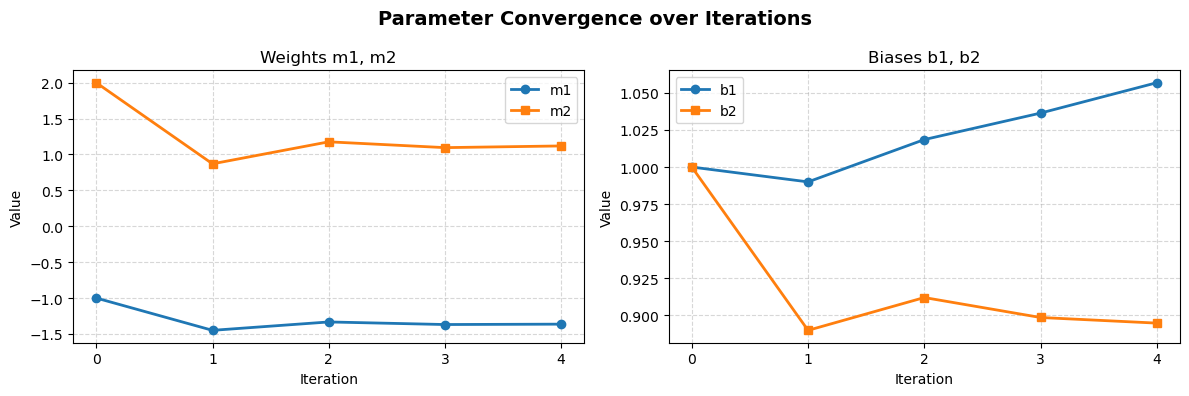

Saved -> plot_parameters.png


In [5]:
history_m_arr = np.array(history_m)   # shape (n_iters+1, 2)
history_b_arr = np.array(history_b)   # shape (n_iters+1, 2)
iters         = np.arange(n_iters + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Parameter Convergence over Iterations", fontsize=14, fontweight="bold")

# Subplot 1 — weights
axes[0].plot(iters, history_m_arr[:, 0], marker="o", linewidth=2, label="m1")
axes[0].plot(iters, history_m_arr[:, 1], marker="s", linewidth=2, label="m2")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Value")
axes[0].set_title("Weights m1, m2")
axes[0].legend()
axes[0].set_xticks(iters)
axes[0].grid(True, linestyle="--", alpha=0.5)

# Subplot 2 — biases
axes[1].plot(iters, history_b_arr[:, 0], marker="o", linewidth=2, label="b1")
axes[1].plot(iters, history_b_arr[:, 1], marker="s", linewidth=2, label="b2")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Value")
axes[1].set_title("Biases b1, b2")
axes[1].legend()
axes[1].set_xticks(iters)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("plot_parameters.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> plot_parameters.png")

## Plot 2 — Error (MSE) Convergence

Shows the Mean Squared Error decreasing with each iteration.

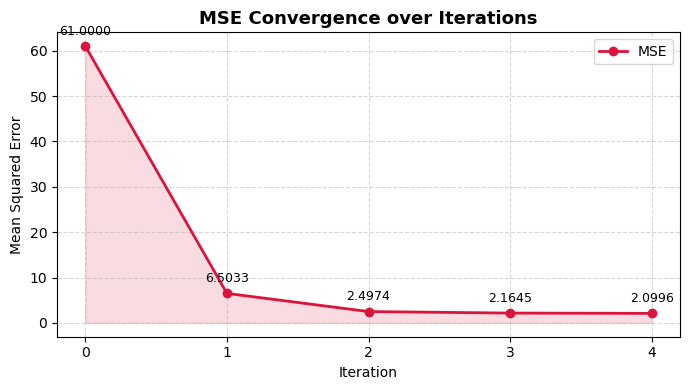

Saved -> plot_mse.png


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(iters, history_mse, marker="o", color="crimson",
        linewidth=2, label="MSE")
ax.fill_between(iters, history_mse, alpha=0.15, color="crimson")

for it, val in zip(iters, history_mse):
    ax.annotate(f"{val:.4f}", xy=(it, val),
                xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=9)

ax.set_xlabel("Iteration")
ax.set_ylabel("Mean Squared Error")
ax.set_title("MSE Convergence over Iterations", fontsize=13, fontweight="bold")
ax.set_xticks(iters)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("plot_mse.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> plot_mse.png")